# Fully Connected Neural Network — House Price Regression

This notebook builds a Keras fully connected neural network to predict Bengaluru house prices (in lakh rupees). It follows a leakage-safe workflow: cleaning first, then train/validation/test splitting, and fitting preprocessing only on the training set.

## 1. Import Libraries and Reproducibility

In [1]:
import os
import random
import warnings

os.environ.setdefault("KERAS_HOME", os.path.abspath(".keras"))
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".mplconfig"))

import numpy as np
import tensorflow as tf

SEED = 42
FAST_RUN = os.getenv("ASSIGNMENT_FAST_RUN", "0") == "1"
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))
print("Fast validation mode:", FAST_RUN)

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input

sns.set_theme(style="whitegrid")

TensorFlow version: 2.20.0
Available GPU devices: []
Fast validation mode: False


## 2. Load Dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/mahmoudramadan155/ML/main/labs/dl/bengaluru_house_prices.csv"
candidate_paths = [
    Path("bengaluru_house_prices.csv"),
    Path("labs/dl/bengaluru_house_prices.csv"),
    Path("../dl/bengaluru_house_prices.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path if data_path else DATA_URL)
print("Loaded from:", data_path if data_path else DATA_URL)
display(df.head())

Loaded from: labs\dl\bengaluru_house_prices.csv


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 3. Initial Data Exploration

In [3]:
print("Dataset shape:", df.shape)
display(df.dtypes.rename("dtype").to_frame())
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (13320, 9)


,dtype
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_type,13320,4,Super built-up Area,8790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability,13320,81,Ready To Move,10581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,13319,1305,Whitefield,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,13304,31,2 BHK,5199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
society,7818,2688,GrrvaGr,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sqft,13320,2117,1200,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath,13247.0,NaN,NaN,NaN,2.69261,1.341458,1.0,2.0,2.0,3.0,40.0
balcony,12711.0,NaN,NaN,NaN,1.584376,0.817263,0.0,1.0,2.0,2.0,3.0
price,13320.0,NaN,NaN,NaN,112.565627,148.971674,8.0,50.0,72.0,120.0,3600.0



Missing values:


,missing
society,5502
balcony,609
bath,73
size,16
location,1
area_type,0
availability,0
total_sqft,0
price,0


Duplicate rows: 529


## 4. Data Cleaning and Feature Engineering

`society` has many missing values and is an identifier-like field, so it is removed. The text `size` field is converted to bedrooms, ranges in `total_sqft` are converted to their midpoint, and availability is simplified to a useful ready/not-ready indicator. Implausible rows are removed with simple domain rules.

In [4]:
def convert_total_sqft(value):
    text = str(value).strip()
    if "-" in text:
        parts = text.split("-")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except (ValueError, IndexError):
            return np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan


clean_df = df.drop_duplicates().copy()
clean_df["bedrooms"] = pd.to_numeric(
    clean_df["size"].astype("string").str.extract(r"(\d+)")[0], errors="coerce"
)
clean_df["total_sqft"] = clean_df["total_sqft"].apply(convert_total_sqft)
clean_df["ready_to_move"] = clean_df["availability"].eq("Ready To Move").astype(int)
clean_df["location"] = clean_df["location"].fillna("Unknown").str.strip()
clean_df["bath"] = clean_df["bath"].fillna(clean_df["bath"].median())
clean_df["balcony"] = clean_df["balcony"].fillna(clean_df["balcony"].median())

clean_df = clean_df.dropna(subset=["bedrooms", "total_sqft", "price"])
clean_df = clean_df[
    (clean_df["price"] > 0)
    & (clean_df["total_sqft"] >= 300)
    & (clean_df["bedrooms"].between(1, 20))
    & (clean_df["bath"] <= clean_df["bedrooms"] + 2)
].copy()
clean_df["sqft_per_room"] = clean_df["total_sqft"] / clean_df["bedrooms"]

model_columns = [
    "area_type", "location", "ready_to_move", "total_sqft",
    "bath", "balcony", "bedrooms", "sqft_per_room", "price"
]
clean_df = clean_df[model_columns]
print("Shape after cleaning:", clean_df.shape)
print("Remaining missing values:", int(clean_df.isna().sum().sum()))
display(clean_df.head())

Shape after cleaning: (12700, 9)
Remaining missing values: 0


,area_type,location,ready_to_move,total_sqft,bath,balcony,bedrooms,sqft_per_room,price
0,Super built-up Area,Electronic City Phase II,0,1056.0,2.0,1.0,2,528.0,39.07
1,Plot Area,Chikka Tirupathi,1,2600.0,5.0,3.0,4,650.0,120.00
2,Built-up Area,Uttarahalli,1,1440.0,2.0,3.0,3,480.0,62.00
3,Super built-up Area,Lingadheeranahalli,1,1521.0,3.0,1.0,3,507.0,95.00
4,Super built-up Area,Kothanur,1,1200.0,2.0,1.0,2,600.0,51.00


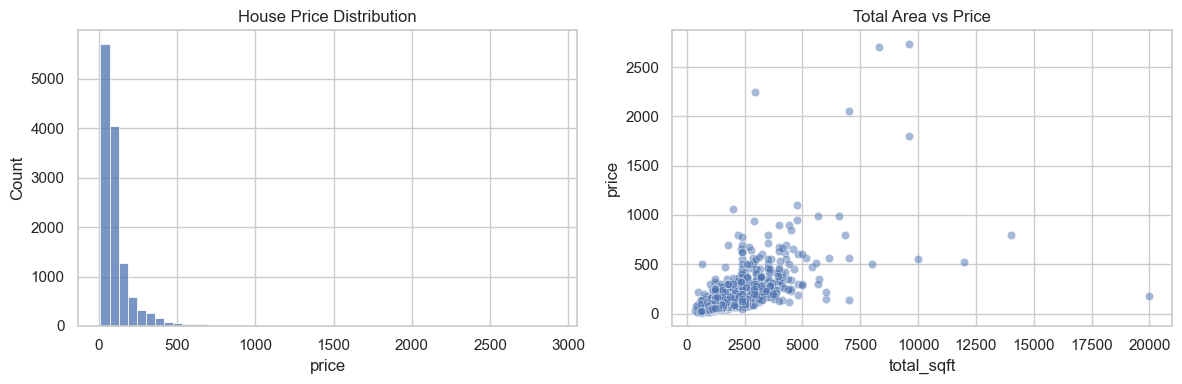

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean_df["price"], bins=50, ax=axes[0])
axes[0].set_title("House Price Distribution")
sns.scatterplot(data=clean_df.sample(min(2500, len(clean_df)), random_state=SEED),
                x="total_sqft", y="price", alpha=0.5, ax=axes[1])
axes[1].set_title("Total Area vs Price")
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

In [6]:
X = clean_df.drop(columns="price")
y = clean_df["price"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

# Learn rare-location handling from the training set only.
location_counts = X_train["location"].value_counts()
common_locations = set(location_counts[location_counts >= 10].index)

def group_locations(frame):
    result = frame.copy()
    result["location"] = result["location"].where(
        result["location"].isin(common_locations), "Other"
    )
    return result

X_train = group_locations(X_train)
X_val = group_locations(X_val)
X_test = group_locations(X_test)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (8890, 8) Validation: (1905, 8) Test: (1905, 8)


## 6. Encoding and Feature Scaling

Numerical columns are standardized and categorical columns are one-hot encoded. The transformer is fit only on training data, preventing validation/test information from influencing preprocessing. The target is modeled as `log(1 + price)` to reduce the effect of the long price tail.

In [7]:
categorical_features = ["area_type", "location"]
numeric_features = [
    "ready_to_move", "total_sqft", "bath", "balcony", "bedrooms", "sqft_per_room"
]
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X_train_ready = preprocessor.fit_transform(X_train).astype("float32")
X_val_ready = preprocessor.transform(X_val).astype("float32")
X_test_ready = preprocessor.transform(X_test).astype("float32")
y_train_log = np.log1p(y_train).astype("float32")
y_val_log = np.log1p(y_val).astype("float32")

print("Processed feature shape:", X_train_ready.shape)

Processed feature shape: (8890, 207)


## 7. Build the Fully Connected Network

The model uses three dense ReLU layers to learn nonlinear relationships between the prepared features. Dropout provides mild regularization, and the single linear output neuron is appropriate for a continuous regression target.

In [8]:
tf.keras.backend.clear_session()
regression_model = Sequential([
    Input(shape=(X_train_ready.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.15),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="linear"),
], name="house_price_fcnn")

regression_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)
regression_model.summary()

Model: "house_price_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        26,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,993 (144.50 KB)

 Trainable params: 36,993 (144.50 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train Model

In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history = regression_model.fit(
    X_train_ready,
    y_train_log,
    validation_data=(X_val_ready, y_val_log),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/60


139/139 - 2s - 11ms/step - loss: 3.6067 - mae: 1.1953 - val_loss: 0.4041 - val_mae: 0.4344 - learning_rate: 1.0000e-03


Epoch 2/60


139/139 - 0s - 2ms/step - loss: 0.4099 - mae: 0.4231 - val_loss: 0.1943 - val_mae: 0.3175 - learning_rate: 1.0000e-03


Epoch 3/60


...

139/139 - 0s - 2ms/step - loss: 0.1058 - mae: 0.2339 - val_loss: 0.0977 - val_mae: 0.2260 - learning_rate: 2.5000e-04


Epoch 24/60


139/139 - 0s - 2ms/step - loss: 0.1029 - mae: 0.2315 - val_loss: 0.0988 - val_mae: 0.2271 - learning_rate: 2.5000e-04


Epoch 25/60


139/139 - 0s - 3ms/step - loss: 0.1019 - mae: 0.2336 - val_loss: 0.0961 - val_mae: 0.2236 - learning_rate: 2.5000e-04


## 9. Training and Validation Loss

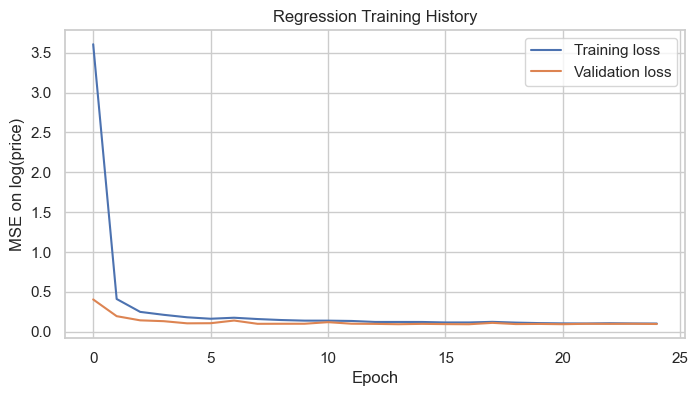

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE on log(price)")
plt.title("Regression Training History")
plt.legend()
plt.show()

## 10. Test Evaluation

In [11]:
predicted_log = regression_model.predict(X_test_ready, verbose=0).ravel()
y_pred = np.maximum(np.expm1(predicted_log), 0)
y_true = y_test.to_numpy()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
regression_results = pd.Series({"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
display(regression_results.to_frame("Test value"))

,Test value
MAE,32.693330
MSE,8632.689891
RMSE,92.912270
R2,0.636165


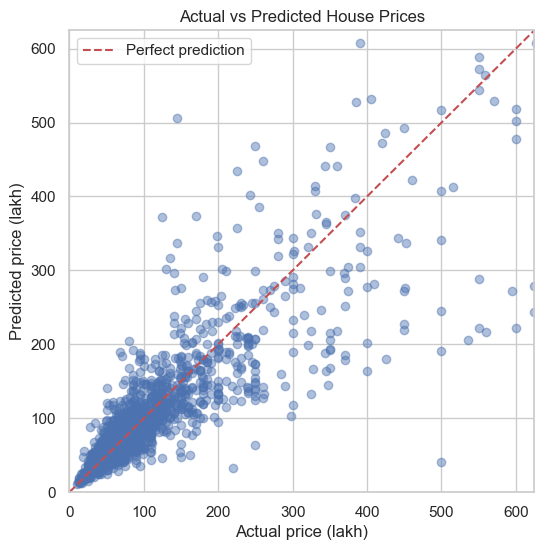

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.45)
limit = np.percentile(np.concatenate([y_true, y_pred]), 99)
ax.plot([0, limit], [0, limit], "r--", label="Perfect prediction")
ax.set(xlim=(0, limit), ylim=(0, limit), xlabel="Actual price (lakh)",
       ylabel="Predicted price (lakh)", title="Actual vs Predicted House Prices")
ax.legend()
plt.show()

## 11. Sample Predictions

In [13]:
sample_predictions = pd.DataFrame({
    "Actual price": y_true[:10],
    "Predicted price": np.round(y_pred[:10], 2),
    "Absolute error": np.round(np.abs(y_true[:10] - y_pred[:10]), 2),
})
display(sample_predictions)

,Actual price,Predicted price,Absolute error
0,120.00,144.509995,24.51
1,50.00,56.660000,6.66
2,180.00,119.830002,60.17
3,230.00,149.119995,80.88
4,170.00,373.149994,203.15
5,45.90,69.540001,23.64
6,550.00,288.570007,261.43
7,67.40,66.349998,1.05
8,100.00,104.379997,4.38
9,32.78,37.730000,4.95


## 12. Conclusion

The fully connected network learned nonlinear relationships among house size, rooms, location, area type, and availability. The printed MAE, RMSE, and R² are calculated from the untouched test set; the actual-versus-predicted plot shows where estimates are strongest and where expensive outliers remain difficult.